In [3]:
# Install required libraries
!pip install tensorflow==2.20.0 matplotlib==3.9.1 scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 67.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 75.5 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.16.2
    Uninstalling tensorboard-2.16.2:
      Successfully uninstalled tensorboard-2.16.2
  Attempting uninstall: tensorflow
    Found existing installation: tensorflow 2.16.2
    Uninstalling tensorflow-2.16.2:
      Successfully uninstalled tensorflow-2.16.2
ERROR: pip's

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


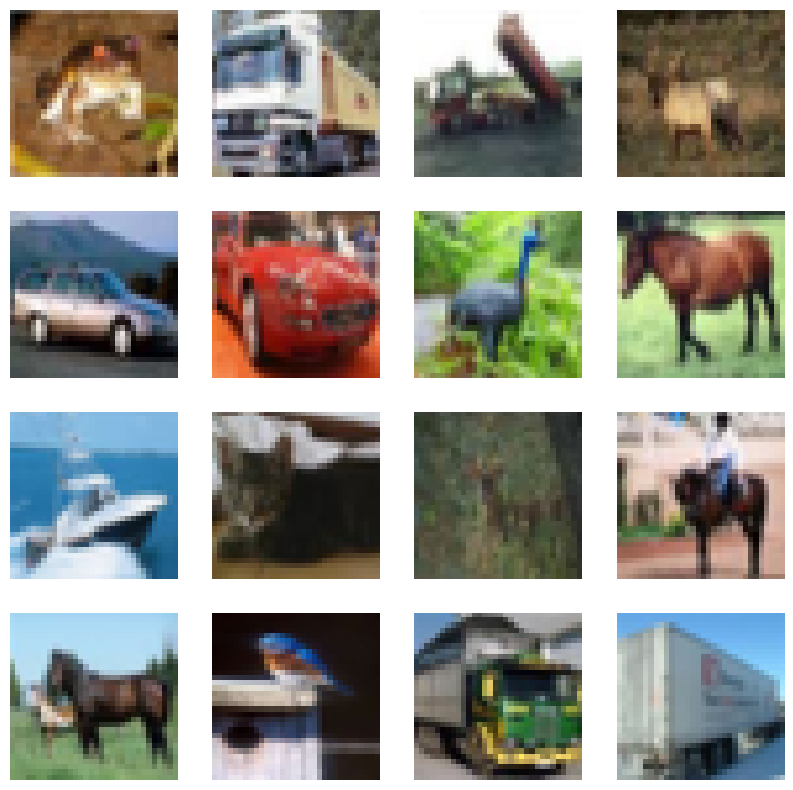

In [1]:

# Import necessary libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Load CIFAR-10 dataset for training images
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Normalize the pixel values for augmentation
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Display a sample of the training images
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_train[i])
    plt.axis('off')
plt.show()


In [2]:
from PIL import Image, ImageDraw

# Create a blank white image
image = Image.new('RGB', (224, 224), color = (255, 255, 255))

# Draw a red square
draw = ImageDraw.Draw(image)
draw.rectangle([(50, 50), (174, 174)], fill=(255, 0, 0))

# Save the image
image.save('sample.jpg')


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load a sample image
img_path = 'sample.jpg'
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

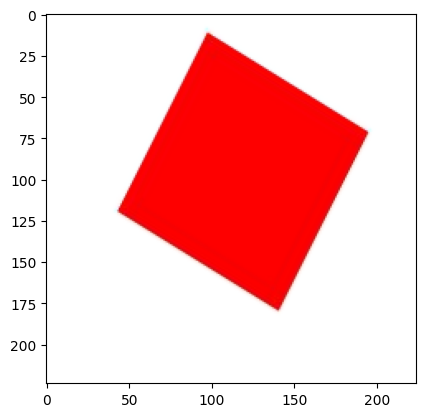

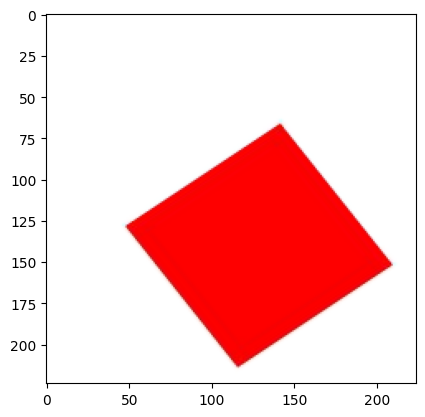

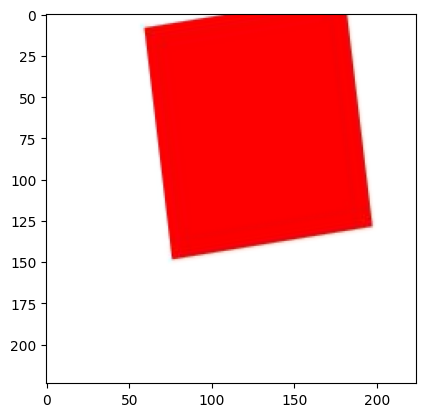

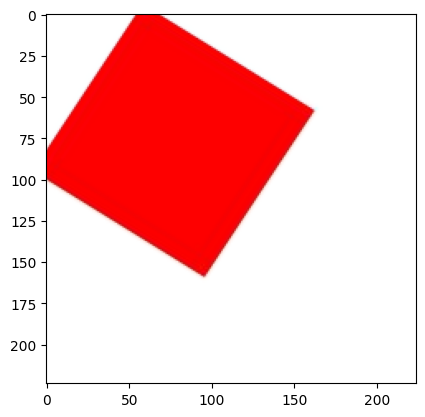

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Load the sample image
img_path = 'sample.jpg'
img = load_img(img_path)
x = img_to_array(img)
x = np.expand_dims(x, axis=0)

# Create an instance of ImageDataGenerator with basic augmentations
datagen = ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generate batches of augmented images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

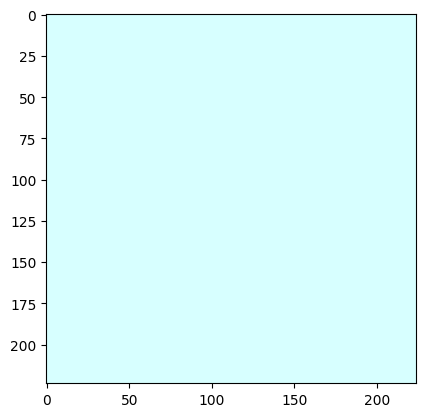

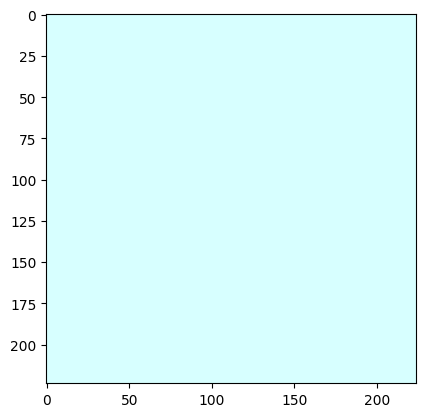

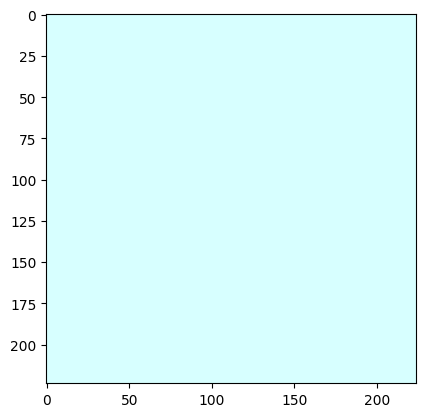

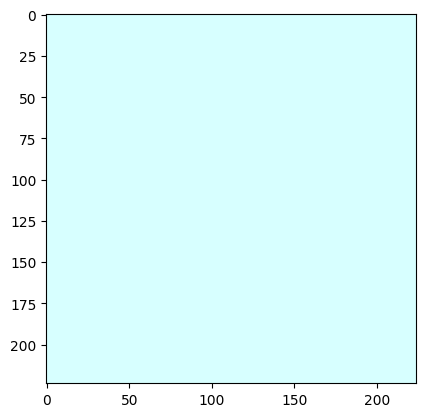

In [5]:
# Create an instance of ImageDataGenerator with normalization options
datagen = ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    samplewise_center=True,
    samplewise_std_normalization=True
)

# Load the sample image again and fit the generator (normally done on the training set)
datagen.fit(x)

# Generate batches of normalized images
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

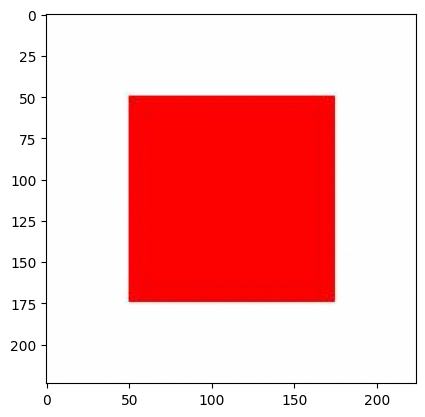

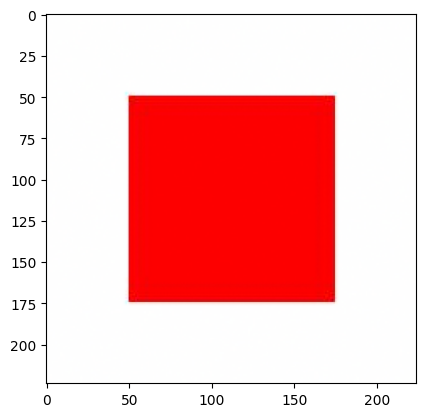

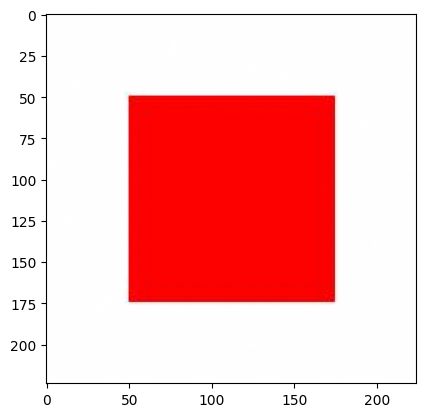

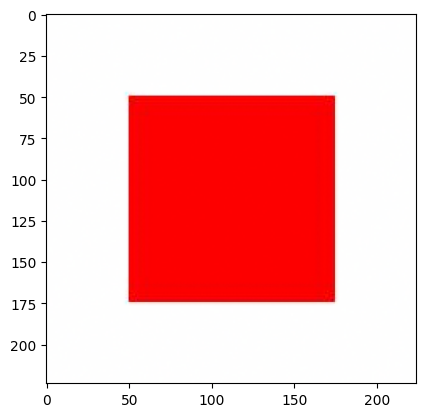

In [6]:
# Define a custom data augmentation function
def add_random_noise(image):
    noise = np.random.normal(0, 0.1, image.shape)
    return image + noise

# Create an instance of ImageDataGenerator with the custom augmentation
datagen = ImageDataGenerator(preprocessing_function=add_random_noise)

# Generate batches of augmented images with noise
i = 0
for batch in datagen.flow(x, batch_size=1):
    plt.figure(i)
    imgplot = plt.imshow(batch[0].astype('uint8'))
    i += 1
    if i % 4 == 0:
        break

plt.show()

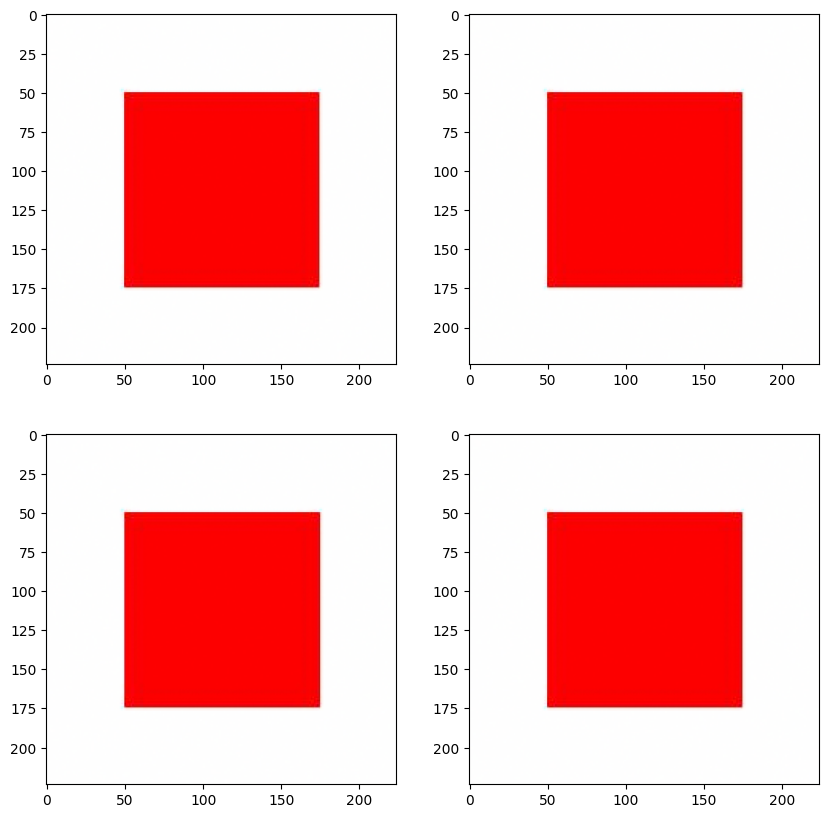

In [7]:
# Visualizing multiple augmented versions of the same image
plt.figure(figsize=(10, 10))
for i, batch in enumerate(datagen.flow(x, batch_size=1)):
    if i >= 4:  # Show only 4 versions
        break
    plt.subplot(2, 2, i+1)
    plt.imshow(batch[0].astype('uint8'))
plt.show()

In [8]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RgP3JFNtPTZA34UmG3KZaA/sample-images.zip
!unzip sample-images.zip

--2026-05-18 12:22:50--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/RgP3JFNtPTZA34UmG3KZaA/sample-images.zip
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14868 (15K) [application/zip]
Saving to: ‘sample-images.zip’

sample-images.zip   100%[===================>]  14.52K  --.-KB/s    in 0.001s  

2026-05-18 12:22:51 (22.9 MB/s) - ‘sample-images.zip’ saved [14868/14868]

Archive:  sample-images.zip
   creating: sample_images/
  inflating: sample_images/training_images1.jpg  
  inflating: sample_images/training_images2.jpg  
  inflating: sample_images/training_images3.jpg  


### Apply and Visualize Different Augmentation Techniques

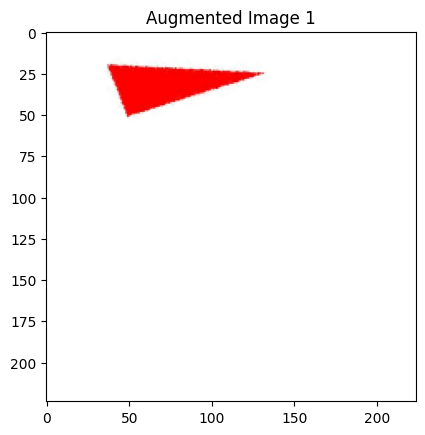

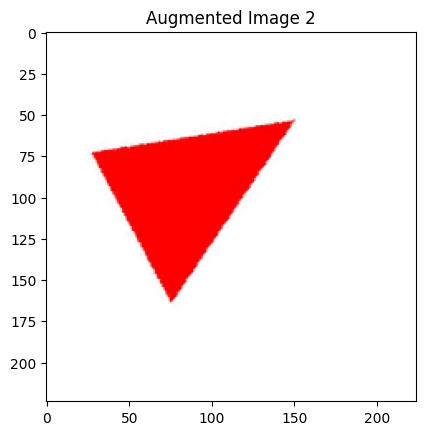

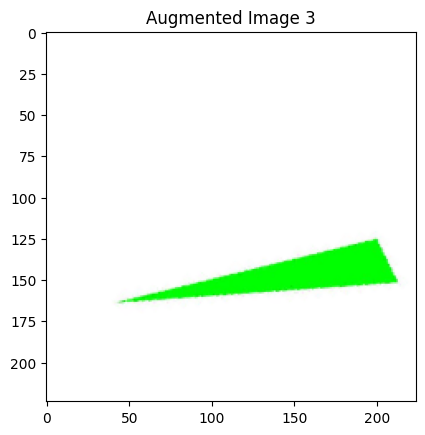

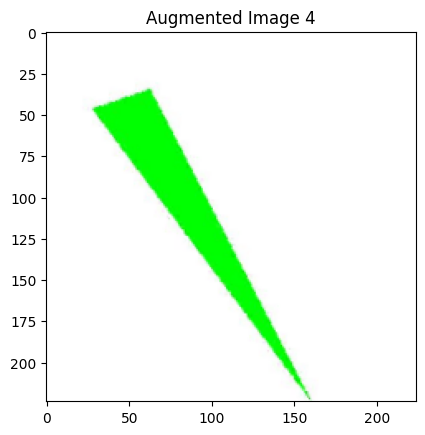

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

import matplotlib.pyplot as plt

import numpy as np



# Define the augmentation parameters

datagen = ImageDataGenerator(

    rotation_range=40,

    width_shift_range=0.2,

    height_shift_range=0.2,

    shear_range=0.2,

    zoom_range=0.2,

    horizontal_flip=True,

    fill_mode='nearest'

)



# Load and preprocess the dataset

image_paths = [

    'sample_images/training_images1.jpg',

    'sample_images/training_images2.jpg',

    'sample_images/training_images3.jpg'

]



training_images = []

for image_path in image_paths:

    img = load_img(image_path, target_size=(224, 224))

    img_array = img_to_array(img)

    training_images.append(img_array)

training_images = np.array(training_images)



# Generate and visualize augmented images

i = 0

for batch in datagen.flow(training_images, batch_size=1):

    plt.figure(i)

    imgplot = plt.imshow(array_to_img(batch[0]))

    plt.title(f'Augmented Image {i + 1}')

    i += 1

    if i % 4 == 0:

        break

plt.show()

### Implement Feature-wise and Sample-wise Normalization

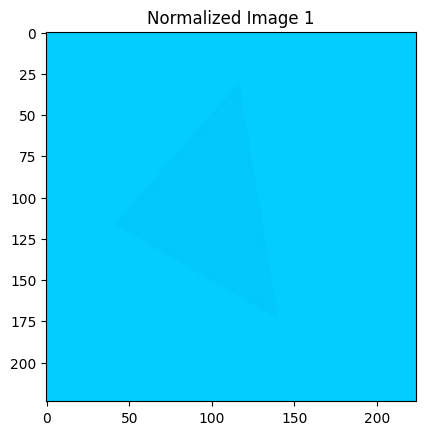

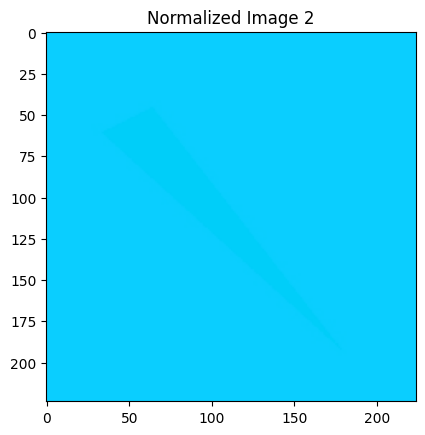

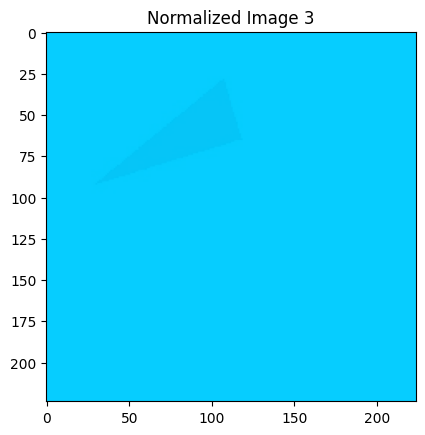

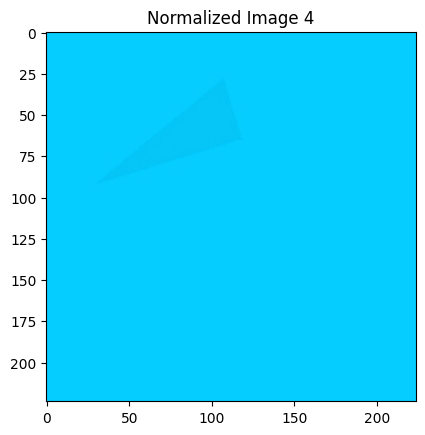

In [10]:
# Create an instance of ImageDataGenerator with normalization options

datagen = ImageDataGenerator(

    featurewise_center=True,

    featurewise_std_normalization=True,

    samplewise_center=True,

    samplewise_std_normalization=True

)



# Fit the ImageDataGenerator to the dataset

datagen.fit(training_images)



# Generate and visualize normalized images

i = 0

for batch in datagen.flow(training_images, batch_size=1):

    plt.figure(i)

    imgplot = plt.imshow(array_to_img(batch[0]))

    plt.title(f'Normalized Image {i + 1}')

    i += 1

    if i % 4 == 0:

        break

plt.show()



### Create and Apply a Custom Data Augmentation Function

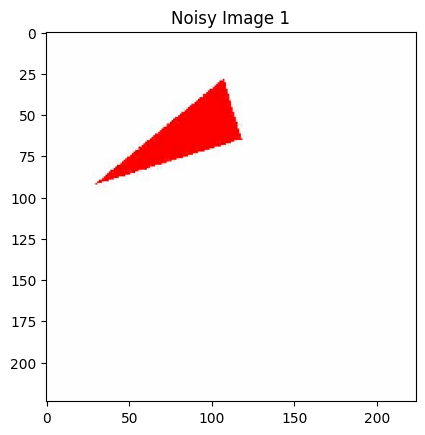

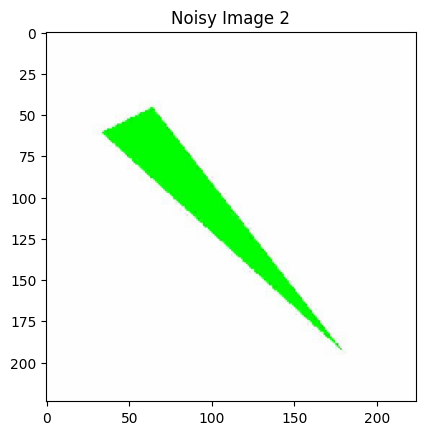

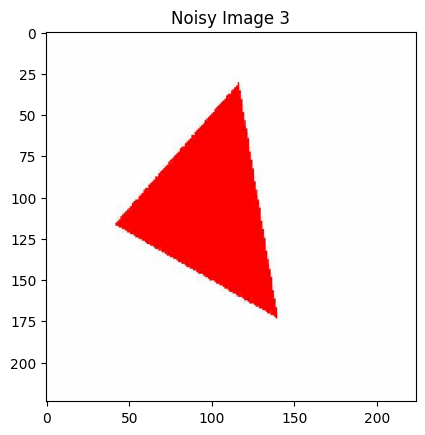

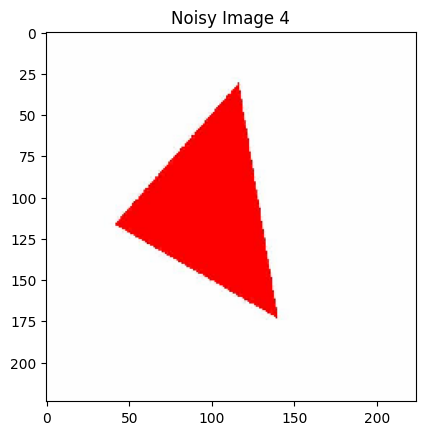

In [11]:
# Define a custom augmentation function to add random noise

def add_random_noise(image):

    noise = np.random.normal(0, 0.1, image.shape)

    return image + noise



# Create an instance of ImageDataGenerator with custom augmentation

datagen = ImageDataGenerator(preprocessing_function=add_random_noise)



# Generate and visualize augmented images

i = 0

for batch in datagen.flow(training_images, batch_size=1):

    plt.figure(i)

    imgplot = plt.imshow(array_to_img(batch[0]))

    plt.title(f'Noisy Image {i + 1}')

    i += 1

    if i % 4 == 0:

        break

plt.show()